In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

# Load dữ liệu
train = pd.read_csv('data/train (1).csv')

In [3]:

# 1. Kiểm tra thông tin tổng quát
print("--- Thông tin tổng quát ---")
print(train.info())

--- Thông tin tổng quát ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14396 entries, 0 to 14395
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Id                  14396 non-null  int64  
 1   Artist Name         14396 non-null  object 
 2   Track Name          14396 non-null  object 
 3   Popularity          14063 non-null  float64
 4   danceability        14396 non-null  float64
 5   energy              14396 non-null  float64
 6   key                 12787 non-null  float64
 7   loudness            14396 non-null  float64
 8   mode                14396 non-null  int64  
 9   speechiness         14396 non-null  float64
 10  acousticness        14396 non-null  float64
 11  instrumentalness    10855 non-null  float64
 12  liveness            14396 non-null  float64
 13  valence             14396 non-null  float64
 14  tempo               14396 non-null  float64
 15  duration_in min/ms  14396

In [4]:

# 2. Kiểm tra giá trị thiếu
missing_data = train.isnull().sum()
print("\n--- Số lượng giá trị thiếu mỗi cột ---")
print(missing_data[missing_data > 0])


--- Số lượng giá trị thiếu mỗi cột ---
Popularity           333
key                 1609
instrumentalness    3541
dtype: int64


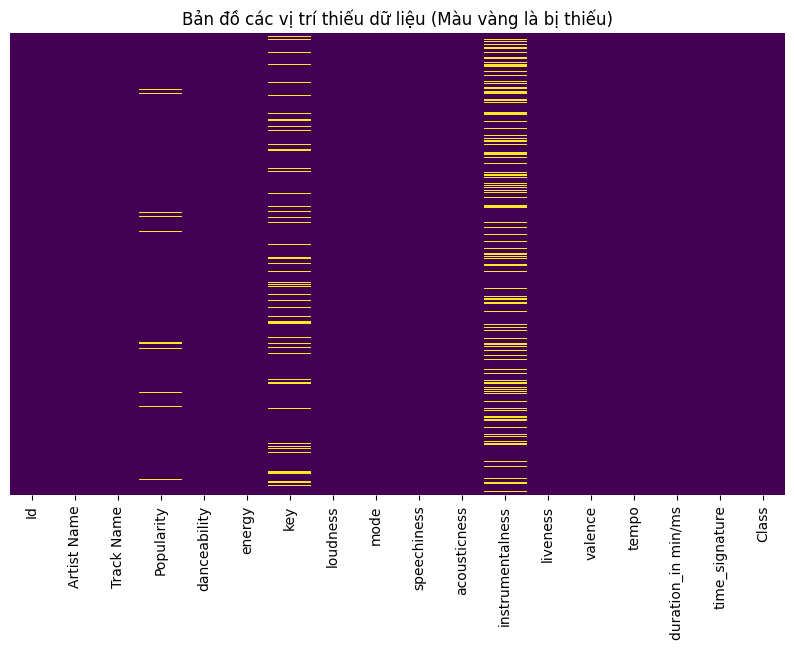

In [5]:

# Trực quan hóa giá trị thiếu
plt.figure(figsize=(10, 6))
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Bản đồ các vị trí thiếu dữ liệu (Màu vàng là bị thiếu)')
plt.show()

C:\Users\HI\AppData\Local\Temp\ipykernel_15272\3947344561.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=train, palette='viridis')


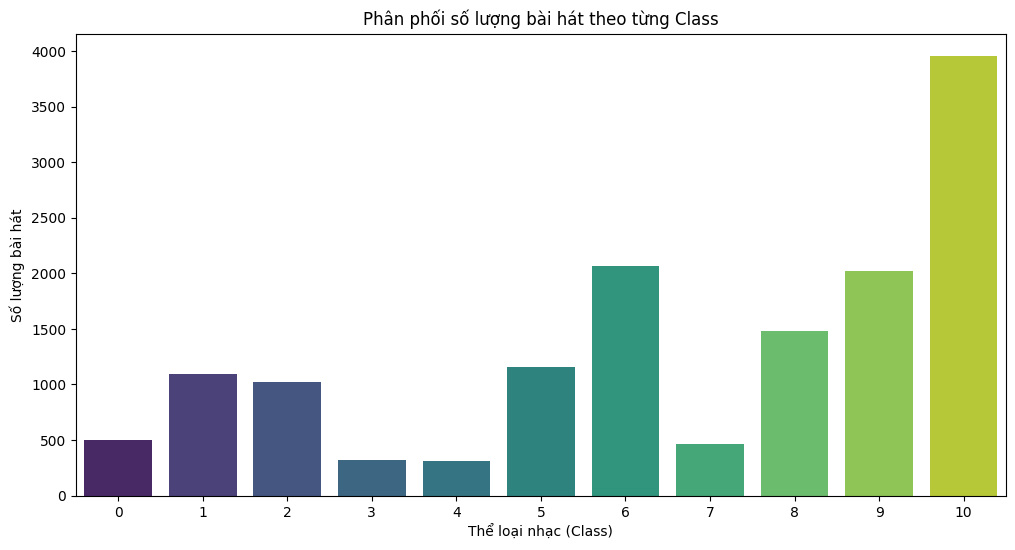

Class
10    27.500695
6     14.372048
9     14.024729
8     10.301473
5      8.036955
1      7.627119
2      7.071409
0      3.473187
7      3.202278
3      2.236732
4      2.153376
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Class', data=train, palette='viridis')
plt.title('Phân phối số lượng bài hát theo từng Class')
plt.xlabel('Thể loại nhạc (Class)')
plt.ylabel('Số lượng bài hát')
plt.show()

# Tính tỷ lệ phần trăm cụ thể
print(train['Class'].value_counts(normalize=True) * 100)

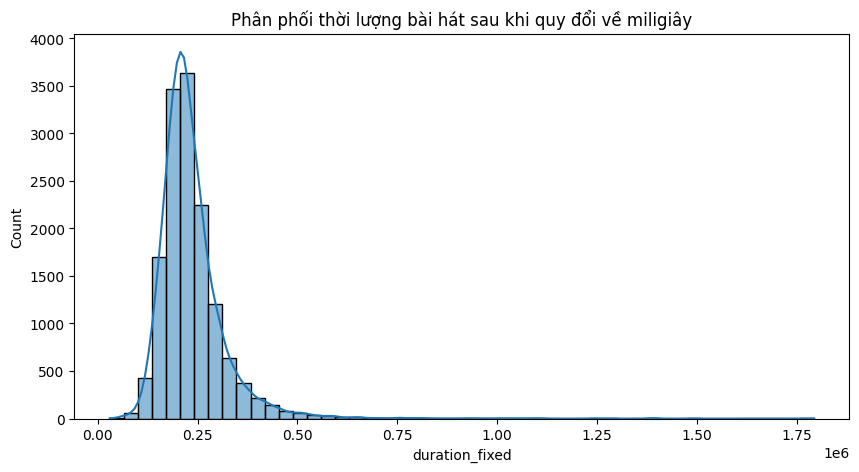

In [7]:
def fix_duration(duration):
    # Nếu thời gian < 30, ta coi đó là phút và đổi sang miligiây (30 phút là ngưỡng an toàn cho 1 bài hát)
    if duration < 30:
        return duration * 60000
    return duration

# Áp dụng hàm sửa lỗi
train['duration_fixed'] = train['duration_in min/ms'].apply(fix_duration)

# Kiểm tra thử kết quả sau khi sửa
plt.figure(figsize=(10, 5))
sns.histplot(train['duration_fixed'], bins=50, kde=True)
plt.title('Phân phối thời lượng bài hát sau khi quy đổi về miligiây')
plt.show()

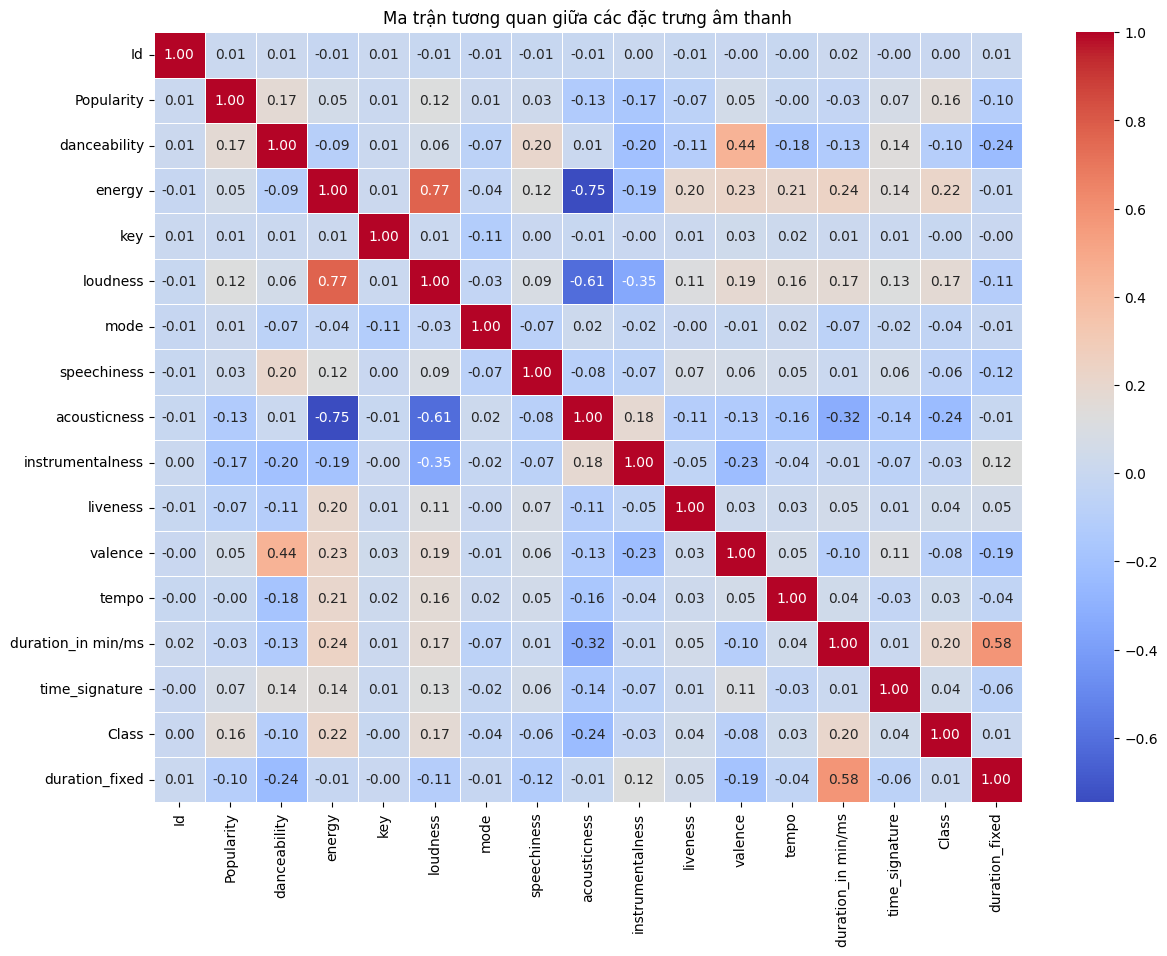

In [8]:
# Chỉ lấy các cột dữ liệu số để tính tương quan
numeric_cols = train.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Ma trận tương quan giữa các đặc trưng âm thanh')
plt.show()

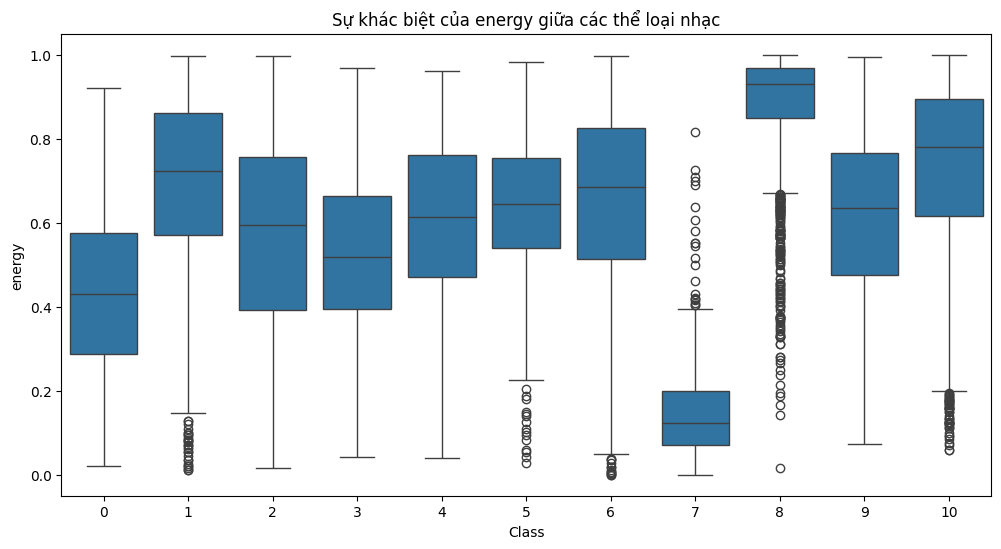

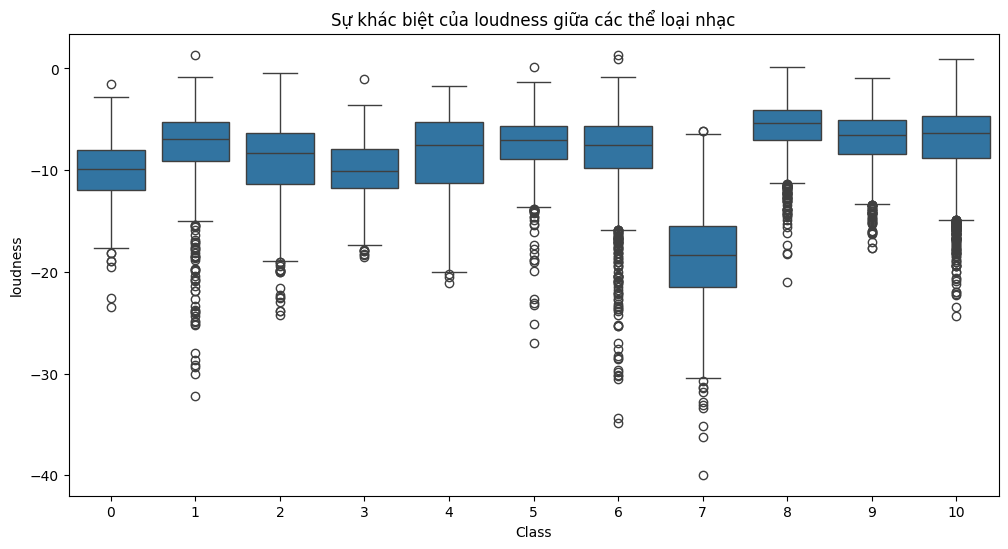

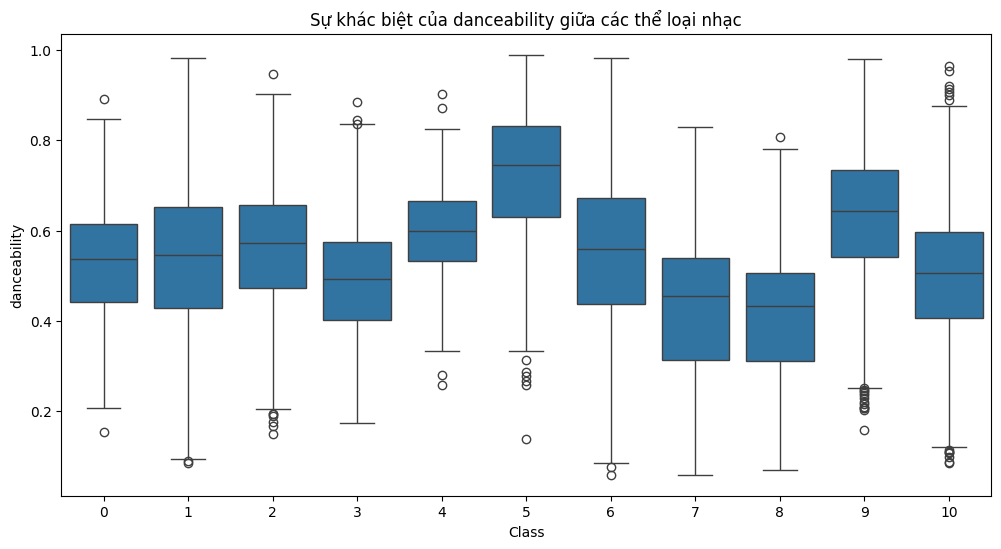

In [9]:
# Ví dụ phân tích sự khác biệt về 'Energy' và 'Loudness' giữa các Class
features_to_plot = ['energy', 'loudness', 'danceability']

for feature in features_to_plot:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Class', y=feature, data=train)
    plt.title(f'Sự khác biệt của {feature} giữa các thể loại nhạc')
    plt.show()